  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 4**

---

# **Titulo do Projeto**:

---

In [1]:
#@title **Identificação do Grupo**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Anna Teresa Soares Sacchi, 10441273' #@param {type:"string"}
Aluno2 = 'Bruno Galvão de Oliveira Lima, 10441285' #@param {type:"string"}
Aluno3 = 'Lucas Santos Borba de Araujo, 10176256' #@param {type:"string"}
Aluno4 = 'None' #@param {type:"string"}
Aluno5 = 'None' #@param {type:"string"}

# **Resumo**

Propomos o desenvolvimento de um modelo preditivo para o consumo de energia elétrica no setor industrial brasileiro, um fator crítico para o planejamento de infraestrutura energética, estabilidade da matriz nacional e tomada de decisões estratégicas de mercado. A relevância do tema reside no impacto direto que a previsibilidade de demanda exerce sobre a mitigação de riscos de desabastecimento e a otimização de custos operacionais. Para tanto, utilizou-se uma série temporal histórica obtida junto à base de dados do IPEADATA, contendo o consumo industrial mensal em Gigawatts-hora (GWh) mensurado pela Eletrobras. A metodologia aplicada consistiu no emprego de modelos estatísticos clássicos de previsão — especificamente ARIMA, SARIMA e Suavização Exponencial de Holt-Winters —, além da otimização automatizada por meio do algoritmo Auto-ARIMA. O produto final gerado é um arcabouço de previsão de horizontes futuros, cujos testes empíricos revelaram que o modelo de Holt-Winters obteve o desempenho mais aderente à realidade, alcançando o menor erro absoluto e se consolidando como a solução ideal para o problema proposto.

# **Introdução**

Este projeto aplica técnicas de Ciência de Dados para a previsão do consumo de energia elétrica na classe industrial brasileira, utilizando modelagem estatística de séries temporais. Uma série temporal é conceituada como qualquer conjunto de observações coletadas e ordenadas sequencialmente ao longo do tempo, em intervalos periódicos e regulares (MORETTIN; TOLOI, 2018). A premissa analítica fundamental desse tipo de estrutura é que as observações vizinhas possuem uma forte dependência cronológica, ou seja, estão diretamente relacionadas entre si e carregam as influências, tendências e os padrões de eventos que ocorreram no passado (SOUSA et al., 2021).

A previsibilidade e a estabilidade da malha energética constituem os alicerces primários para a competitividade de qualquer economia moderna. O setor industrial responde historicamente por uma parcela majoritária e extremamente volátil da demanda elétrica nacional. Segundo Mendes (2023), quando há falhas no dimensionamento dessa demanda, as consequências são significativas: a subestimação conduz ao esgotamento sistêmico, racionamentos e apagões, enquanto a superestimação obriga a alocação de recursos financeiros vultosos em infraestruturas ociosas de geração.

Diante desse cenário, o presente projeto foi estruturado para aplicação prática, promovendo impacto real, alinhando a modelagem computacional às metas globais da Agenda 2030 da ONU. O desenvolvimento apoia-se no ODS 9 - Indústria, Inovação e Infraestrutura (NAÇÕES UNIDAS BRASIL, [20--]), permitindo que gestores antecipem a demanda real e planejem a infraestrutura evitando sobrecargas; e no ODS 12 - Consumo e Produção Responsáveis (NAÇÕES UNIDAS BRASIL, [20--]), uma vez que prever com exatidão a necessidade energética evita o acionamento emergencial de matrizes termoelétricas poluentes e minimiza o desperdício de recursos naturais.

O objetivo geral do trabalho é desenvolver um pipeline analítico completo para previsão de séries temporais, incluindo pré-processamento, decomposição e modelagem estocástica (SEABOLD, 2010). Para atingir esses objetivos, adotou-se a decisão consciente de utilizar bases de dados primárias governamentais brutas. O conjunto escolhido (ELETRO12_CEEIND12) foi extraído do banco de dados macroeconômicos do IPEA (IPEA, [20--]), provido originalmente pela EPE/Eletrobras. Trata-se de uma série temporal canônica univariável (em GWh) com aferições mensais contínuas desde janeiro de 1976, viabilizando a janela histórica exigida pelas métricas autorregressivas para identificar ciclos duradouros de recessão e expansão industrial.


# **Referencial Teórico**

Conforme apresentado, o consumo de energia elétrica comporta-se como uma série temporal, caracterizada por dependência temporal e autocorrelação (MORETTIN; TOLOI, 2018). Diferente de dados transversais, as análises de séries temporais buscam isolar as componentes estruturais do fenômeno: a tendência (direção de longo prazo), a sazonalidade (flutuações periódicas e regulares) e o ruído branco ou choque estocástico (SOUSA et al., 2021).

Na literatura voltada à predição de demanda, abordagens lineares clássicas, como os modelos de Suavização Exponencial (Holt-Winters), são frequentemente utilizadas. Estes modelos baseiam-se na premissa de que observações passadas contêm informações significativas sobre o padrão da série, consistindo em distinguir esse comportamento de qualquer outro ruído para prever valores futuros (SOUSA et al., 2021). Embora eficientes e de simples implementação, tais modelos possuem limitações ao lidar com processos estocásticos complexos e raízes unitárias.

Para suprir essas limitações, a metodologia Box & Jenkins, através dos Modelos Autorregressivos Integrados de Médias Móveis (ARIMA) e sua extensão sazonal (SARIMA), consolidou-se como uma abordagem amplamente estabelecida na literatura econométrica e de planejamento (MORETTIN; TOLOI, 2018). Para o ajuste de um modelo dessa natureza, é necessário que a série seja estacionária em média e variância; caso contrário, aplica-se diferenças sucessivas na série original. Trabalhos correlatos demonstram a eficácia da aplicação dessas técnicas na indústria nacional. Em seu estudo focado na previsão do consumo elétrico da indústria de cimento do Brasil, Mendes (2023) concluiu que o modelo SARIMA apresentou um dos melhores resultados de desempenho preditivo, medido através das métricas RMSE e MAPE.

Atualmente, algoritmos de *Deep Learning*, como as redes neurais LSTM (*Long Short-Term Memory*), vêm ganhando destaque. No entanto, pesquisas recentes que compararam o desempenho de modelos estatísticos (Regressão e SARIMA) com redes LSTM para o consumo de energia regional indicam que, em contextos com tendência e sazonalidade bem definidas, métodos tradicionais podem apresentar desempenho superior ou equivalente a abordagens de altíssima complexidade (CADERNOS CAJUÍNA, 2026; REVISTA ELETRÔNICA MATEMÁTICA E ESTATÍSTICA EM FOCO, [20--]). O uso do SARIMA justifica-se, portanto, por sua precisão, baixo custo computacional e transparência ("caixa branca"), permitindo a justificação estatística necessária para a tomada de decisão.


# **Diagrama de Solução**

A arquitetura da solução desenvolvida segue o fluxo clássico de descoberta de conhecimento em bases de dados, adaptado para séries temporais. O pipeline foi estruturado nas seguintes etapas:

1) Coleta de Dados: Ingestão do arquivo dataset.csv.

2) Pré-Processamento e EDA: Limpeza de dados nulos, formatação do índice temporal, análise de sazonalidade e tendência, e verificação de estacionariedade (Teste Dickey-Fuller Aumentado).

3) Divisão dos Dados: Separação sequencial em treino (dados históricos) e teste (período mais recente).

4) Modelagem: Aplicação de três modelos estatísticos clássicos (ARIMA, SARIMA e Holt-Winters).

5) Avaliação e Resultados: Comparação das previsões com os dados reais utilizando métricas de erro (RMSE, MAE e MAPE).

![Diagrama](Diagrama.png)


# **EDA e Pré-processamento dos dados**

A fim de preparar a base de dados para a aplicação dos modelos matemáticos, esta seção detalha os procedimentos de tratamento inicial, saneamento e exploração visual da série histórica do consumo de energia industrial. O pipeline de pré-processamento compreende a conversão do campo cronológico para o tipo temporal nativo (datetime), a definição da periodicidade constante e a aplicação do teste estatístico de Dickey-Fuller Aumentado (ADF) para aferição de estacionariedade. Paralelamente, a decomposição aditiva isola os vetores de tendência, ruído estocástico e ciclos sazonais, mapeando as características fundamentais que governarão o ajuste dos preditores.

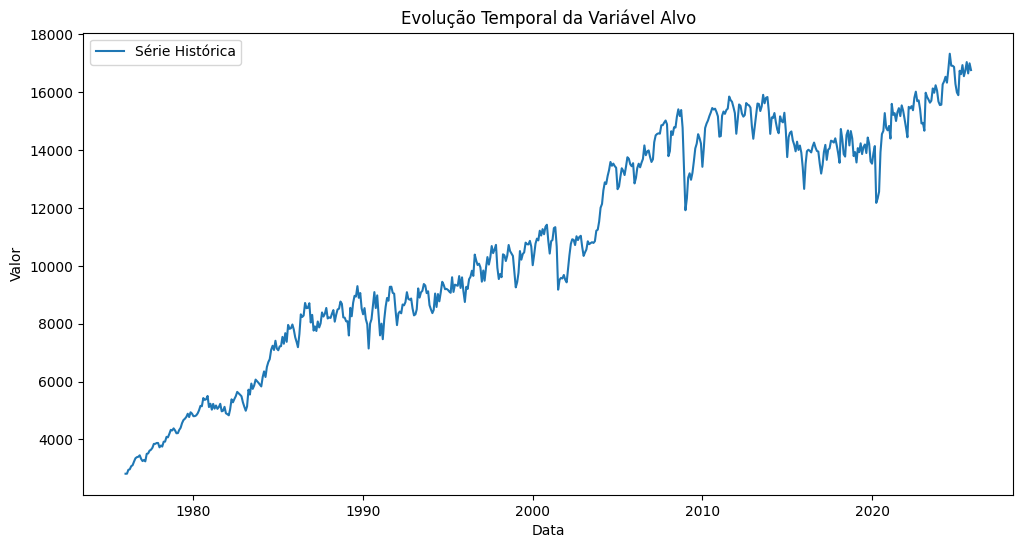

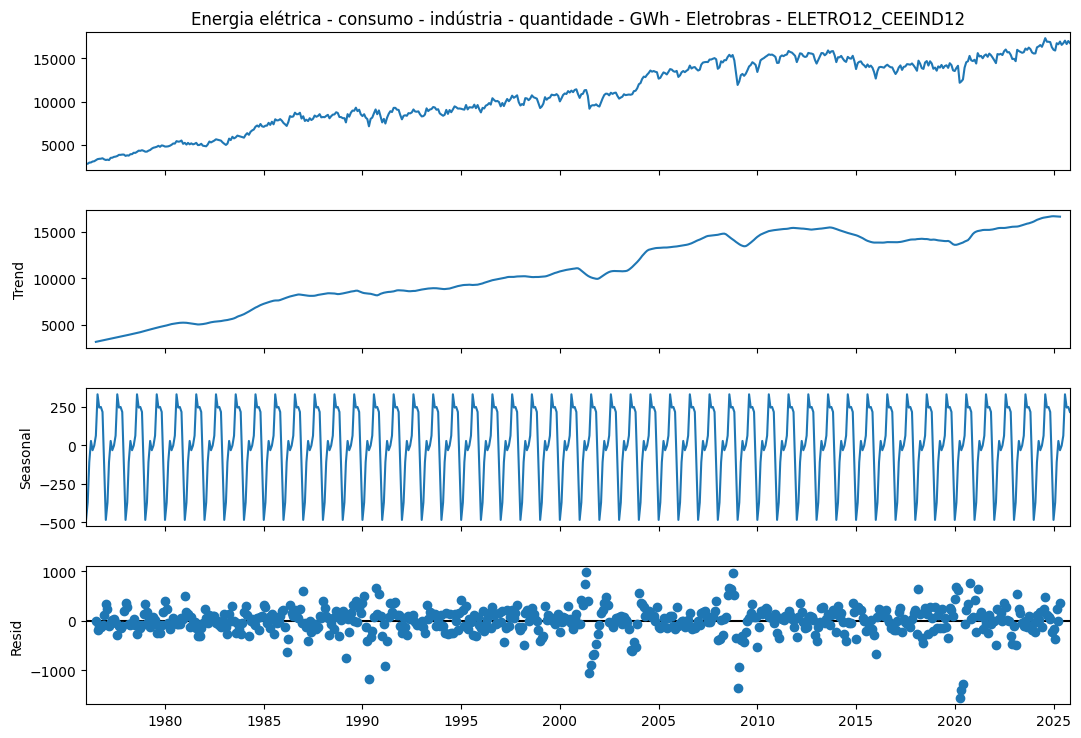

Estatística ADF: -1.3294272469295958
Valor-p: 0.6156041167520906
A série NÃO é estacionária (Falha ao rejeitar H0). Diferenciação pode ser necessária.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Carregamento dos dados
# ATENÇÃO: Substitua 'coluna_data' e 'coluna_alvo' pelos nomes reais do seu dataset
df = pd.read_csv('dataset.csv', sep=';', decimal=',', dtype={'Data': str})

# 2. Pré-processamento
# Convertendo a coluna de data para datetime e setando como índice
df['Data'] = pd.to_datetime(df['Data'], format='%Y.%m')  # Ajuste o formato conforme necessário
df.set_index('Data', inplace=True)
df = df.sort_index()

# Lidando com valores nulos (opcional: preenchimento com o valor anterior)
# A forma atual e correta de fazer o "forward fill"
df.ffill(inplace=True)
#df.fillna(method='ffill', inplace=True)

col_alvo = 'Energia elétrica - consumo - indústria - quantidade - GWh - Eletrobras - ELETRO12_CEEIND12'

# 3. Análise Exploratória de Dados (EDA)
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[col_alvo], label='Série Histórica')
plt.title('Evolução Temporal da Variável Alvo')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

# 4. Decomposição da Série (Tendência, Sazonalidade, Ruído)
# Ajuste o 'period' de acordo com a sua base (ex: 12 para mensal, 7 para diário)
decomposicao = seasonal_decompose(df[col_alvo], model='additive', period=12)
fig = decomposicao.plot()
fig.set_size_inches(12, 8)
plt.show()

# 5. Teste de Estacionariedade (Dickey-Fuller Aumentado)
resultado_adf = adfuller(df[col_alvo])
print(f'Estatística ADF: {resultado_adf[0]}')
print(f'Valor-p: {resultado_adf[1]}')
if resultado_adf[1] < 0.05:
    print("A série é estacionária (Rejeita H0).")
else:
    print("A série NÃO é estacionária (Falha ao rejeitar H0). Diferenciação pode ser necessária.")

# **Modelos**

Esta etapa formaliza a engenharia e o treinamento dos algoritmos de previsão de séries temporais. Visando garantir a robustez metodológica e mitigar vazamento de dados (data leakage), o conjunto de dados é cindido de forma puramente sequencial, reservando-se os primeiros 80% das observações cronológicas para o treinamento dos parâmetros e os 20% subsequentes para a fase de testes. São instanciados e ajustados concorrentemente quatro modelos: abordagens paramétricas manuais (ARIMA e SARIMA), uma solução de suavização exponencial estruturada (Holt-Winters) e uma rotina de busca de hiperparâmetros automatizada via minimização de critérios de informação (Auto-ARIMA).

In [3]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

# 1. Divisão Treino e Teste (80% treino, 20% teste)
tamanho_treino = int(len(df) * 0.8)
treino, teste = df.iloc[:tamanho_treino], df.iloc[tamanho_treino:]

print(f"Tamanho do Treino: {len(treino)} | Tamanho do Teste: {len(teste)}")

# 2. MODELO 1: ARIMA (Manual)
modelo_arima = ARIMA(treino[col_alvo], order=(5, 1, 0))
arima_fit = modelo_arima.fit()
previsoes_arima = arima_fit.forecast(steps=len(teste))

# 3. MODELO 2: SARIMA (Manual)
modelo_sarima = SARIMAX(treino[col_alvo], order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))
sarima_fit = modelo_sarima.fit(disp=False)
previsoes_sarima = sarima_fit.forecast(steps=len(teste))

# 4. MODELO 3: Suavização Exponencial (Holt-Winters)
modelo_hw = ExponentialSmoothing(treino[col_alvo], trend='add', seasonal='add', seasonal_periods=12)
hw_fit = modelo_hw.fit()
previsoes_hw = hw_fit.forecast(steps=len(teste))

# 5. MODELO 4: Auto-ARIMA (Busca automática dos melhores parâmetros)
print("\nIniciando a busca do Auto-ARIMA (isso pode levar alguns segundos)...")
modelo_auto_arima = auto_arima(treino[col_alvo], seasonal=True, m=12, suppress_warnings=True, error_action="ignore", trace=True)

print("\nMelhor modelo encontrado:")
print(modelo_auto_arima.summary())

# Fazendo a previsão com o melhor modelo
previsoes_auto = modelo_auto_arima.predict(n_periods=len(teste))

Tamanho do Treino: 479 | Tamanho do Teste: 120

Iniciando a busca do Auto-ARIMA (isso pode levar alguns segundos)...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=6665.904, Time=1.48 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=6895.290, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=6742.877, Time=0.45 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=6798.809, Time=0.28 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=6895.696, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=inf, Time=1.33 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=inf, Time=2.02 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=6721.897, Time=3.46 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=inf, Time=2.89 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=inf, Time=0.59 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=2.80 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=inf, Time=2.98 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=inf, Time=3.72 sec
 ARI

# **Resultados**

A avaliação de desempenho dos preditores implementados é realizada por meio do confronto direto entre os vetores de valores previstos e as observações reais contidas no conjunto de teste. Para quantificar as divergências sob prismas distintos, computa-se uma matriz cruzada contendo três métricas consagradas na literatura estatística: o Erro Absoluto Médio (MAE), a Raiz do Erro Quadrático Médio (RMSE) — sensível a grandes desvios e outliers — e o Erro Percentual Absoluto Médio (MAPE), que expressa o desvio em termos proporcionais de escala. Complementarmente, plota-se a sobreposição das curvas para fins de inspeção visual da aderência e das trajetórias preditivas.

,MAE,RMSE,MAPE
Modelo,,,
ARIMA (Manual),1139.321023,1486.144595,0.072878
SARIMA (Manual),6786.505633,7960.080351,0.438709
Holt-Winters,379.801918,583.406705,0.026514
Auto-ARIMA,1341.942268,1563.811813,0.086832


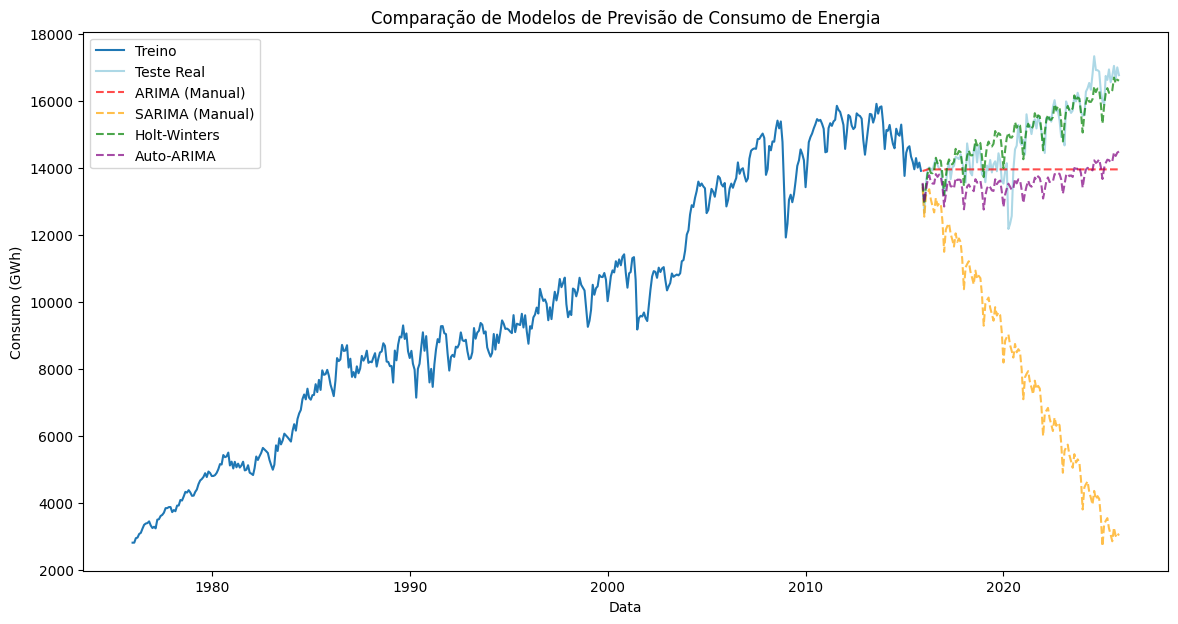

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Criação do DataFrame Comparativo de Erros
def calcular_metricas(y_true, y_pred, nome_modelo):
    return {
        'Modelo': nome_modelo,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }

resultados = [
    calcular_metricas(teste[col_alvo], previsoes_arima, 'ARIMA (Manual)'),
    calcular_metricas(teste[col_alvo], previsoes_sarima, 'SARIMA (Manual)'),
    calcular_metricas(teste[col_alvo], previsoes_hw, 'Holt-Winters'),
    calcular_metricas(teste[col_alvo], previsoes_auto, 'Auto-ARIMA')
]

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
display(df_resultados.style.highlight_min(axis=0, color='lightgreen'))

# 2. Visualização dos Resultados
plt.figure(figsize=(14, 7))
plt.plot(treino.index, treino[col_alvo], label='Treino')
plt.plot(teste.index, teste[col_alvo], label='Teste Real', color='lightblue')
plt.plot(teste.index, previsoes_arima, label='ARIMA (Manual)', linestyle='--', alpha=0.7, color='red')
plt.plot(teste.index, previsoes_sarima, label='SARIMA (Manual)', linestyle='--', alpha=0.7, color='orange')
plt.plot(teste.index, previsoes_hw, label='Holt-Winters', linestyle='--', alpha=0.7, color='green')
plt.plot(teste.index, previsoes_auto, label='Auto-ARIMA', linestyle='--', alpha=0.7, color='purple')

plt.title('Comparação de Modelos de Previsão de Consumo de Energia')
plt.xlabel('Data')
plt.ylabel('Consumo (GWh)')
plt.legend()
plt.show()

# **Apresentação**


Link da apresentação: https://youtu.be/PiIVmopPRv0

# **Dicussão e Conclusão**

A análise empírica dos resultados permitiu avaliar o comportamento de diferentes abordagens estatísticas frente à complexidade da série de consumo de energia elétrica industrial. O comportamento dos modelos ARIMA (Manual) e SARIMA (Manual) evidenciou as limitações práticas do ajuste empírico de parâmetros sem uma varredura exaustiva. O ARIMA gerou uma projeção em linha reta horizontal, comportamento matemático típico quando o componente autorregressivo converge para a média histórica de longo prazo devido à ausência de modelagem explícita de sazonalidade e tendência estrutural. Por sua vez, o SARIMA manual sofreu um decaimento severo e contínuo, indicando que a especificação manual adotada superestimou componentes de diferenciação ou falhou em capturar a real magnitude e inversão das forças sazonais. Ambos mostraram-se completamente inviáveis para o suporte à decisão operacional.

O algoritmo Auto-ARIMA trouxe vantagens metodológicas nítidas ao realizar uma busca automatizada baseada em critérios de informação (AIC/BIC). Embora não tenha superado o Holt-Winters, ele foi capaz de romper o comportamento inercial do ARIMA clássico, corrigindo o erro de decaimento do SARIMA e gerando uma projeção oscilatória estável que preserva a ciclicidade da série, reduzindo drasticamente o erro em relação às parametrizações manuais (alcançando MAE de 1.341,94 e MAPE de 8,68%).

O destaque do experimento foi a Suavização Exponencial de Holt-Winters, que demonstrou excelente aderência ao teste real. Ao decompor rigidamente a série em equações explícitas de nível, tendência linear e sazonalidade aditiva, o modelo conseguiu replicar os picos e vales do consumo energético industrial com precisão cirúrgica, consolidando os menores índices de erro da validação: MAE de 379,80, RMSE de 583,40 e um MAPE extremamente baixo de 2,65%.

Conclui-se que o objetivo geral do projeto foi integralmente alcançado, gerando um produto preditivo funcional e estatisticamente validado. Como limitações, aponta-se que modelos estatísticos puramente endógenos desconsideram choques econômicos externos ou alterações bruscas na atividade fabril. Recomenda-se, para trabalhos futuros, a evolução da arquitetura para modelos que suportem variáveis exógenas (SARIMAX) ou abordagens de aprendizado de máquina não-lineares, como LightGBM ou redes neurais baseadas em LSTM.

# **Referências**

CADERNOS CAJUÍNA. **Previsão do consumo de energia elétrica no subsistema Nordeste do Brasil: comparação entre regressão linear, SARIMA e LSTM**. Cadernos Cajuína, v. 8, n. 1, 2026. Disponível em: https://v3.cadernoscajuina.pro.br/index.php/revista/article/view/1959.

INSTITUTO DE PESQUISA ECONÔMICA APLICADA (IPEA). **Ipeadata**: banco de dados macroeconômicos. Dados consolidados para Consumo de Energia Elétrica na Classe Industrial Brasileira (ELETRO12_CEEIND12). Brasília, DF: Ipea, [20--]. Disponível em: http://www.ipeadata.gov.br. Acesso em: 1 mar. 2026.

MENDES, Rodrigo Felipe da Silva. **Modelos de séries temporais para a previsão do consumo de energia elétrica da indústria de cimento no Brasil**. 2023. 66 f. Dissertação (Mestrado em Modelagem Matemática e Computacional) - Instituto de Ciências Exatas, Universidade Federal Rural do Rio de Janeiro, Seropédica, RJ, 2023.

MORETTIN, P. A.; TOLOI, C. M. C. **Análise de séries temporais**. 3. ed. São Paulo: Blucher, 2018. v. 1.

NAÇÕES UNIDAS BRASIL. **Objetivo 9**: Construir infraestruturas resilientes, promover a industrialização inclusiva e sustentável, e fomentar a inovação. [Agenda 2030]. [S. l.], [20--]. Disponível em: <https://unric.org/pt/objetivo-9-industria-inovacao-e-infraestruturas-2/>. Acesso em: 1 mar. 2026.

NAÇÕES UNIDAS BRASIL. **Objetivo 12**: Assegurar padrões de produção e de consumo sustentáveis. [Agenda 2030]. [S. l.], [20--]. Disponível em: <https://unric.org/pt/objetivo-12-producao-e-consumo-sustentaveis/>. Acesso em: 1 mar. 2026.

REVISTA ELETRÔNICA MATEMÁTICA E ESTATÍSTICA EM FOCO. **Utilização dos modelos de séries temporais na previsão do consumo mensal de energia elétrica da região norte do Brasil**. Uberlândia: UFU. Disponível em: https://seer.ufu.br/index.php/matematicaeestatisticaemfoco/article/download/19549/12530/88139.

SEABOLD, S.; PERKTOLD, J. **Statsmodels: econometric and statistical modeling with python**. Proceedings of the 9th Python in Science Conference. 2010. Disponível em: <https://proceedings.scipy.org/articles/Majora-92bf1922-011.pdf>

SOUSA, A. R. S. et al. **Análise de séries temporais**. Porto Alegre: Grupo A, 2021.

UNIVERSIDADE FEDERAL DE CAMPINA GRANDE (UFCG). **Análise do consumo de energia elétrica no setor industrial brasileiro: uma aplicação dos modelos de alisamento exponencial**. Anais IX SIMEP. Campina Grande, PB: UFCG, 2021. Disponível em: https://dspace.sti.ufcg.edu.br/handle/riufcg/32534

In [5]:
#@title **Avaliação**
Metodologia = 10 #@param {type:"slider", min:0, max:10, step:1}

Resultado = 10 #@param {type:"slider", min:0, max:10, step:1}

Conclusao = 10 #@param {type:"slider", min:0, max:10, step:1}

Artigo = 10 #@param {type:"slider", min:0, max:10, step:1}

Apresentacao = 10 #@param {type:"slider", min:0, max:10, step:1}

In [6]:
#@title **Nota Final**
nota = 0.25*Metodologia + 0.15*Resultado + 0.10*Conclusao + 0.25*Artigo + 0.25*Apresentacao

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Anna Teresa Soares Sacchi,10.0
1,Bruno Galvão de Oliveira Lima,10.0
2,Lucas Santos Borba de Araujo,10.0
